#  <font color='#FFE15D'><b>💎 Introduction to RL</b></font>

# 🔴 **Environment**

In [5]:
import gymnasium as gym

# Initialise the environment
env = gym.make("LunarLander-v3", render_mode="human")

# Reset the environment to generate the first observation
observation, info = env.reset(seed=42)
for _ in range(1000):
    # this is where you would insert your policy
    action = env.action_space.sample()

    # step (transition) through the environment with the action
    # receiving the next observation, reward and if the episode has terminated or truncated
    observation, reward, terminated, truncated, info = env.step(action)

    # If the episode has ended then we can reset to start a new episode
    if terminated or truncated:
        observation, info = env.reset()

env.close()

In [10]:
print(f"Action space: {env.action_space}")  
print(f"Sample action: {env.action_space.sample()}")

# Box observation space (continuous values)
print(f"Observation space: {env.observation_space}") 
print(f"Sample observation: {env.observation_space.sample()}") 

Action space: Discrete(4)
Sample action: 3
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Sample observation: [ 1.3200408  -2.471043    2.3641565   2.1212351   4.345064    0.7342591
  0.24154903  0.9018063 ]


# 🔴 **Agent**

## 🟠 Learning

In [14]:
import gymnasium as gym
from stable_baselines3 import PPO

# Initialize the environment with a custom time limit (handles 'truncated')
env = gym.make("LunarLander-v3", render_mode="human", max_episode_steps=600)

# Define the PPO agent using an MLP (Multi-Layer Perceptron) policy
model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003)

# Train the agent
print("--- Starting Training Process ---")
model.learn(total_timesteps=10_000)
print("--- Training Completed Successfully! ---")

env.close()

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
--- Starting Training Process ---
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 97.4     |
|    ep_rew_mean     | -196     |
| time/              |          |
|    fps             | 46       |
|    iterations      | 1        |
|    time_elapsed    | 43       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 97.2        |
|    ep_rew_mean          | -174        |
| time/                   |             |
|    fps                  | 45          |
|    iterations           | 2           |
|    time_elapsed         | 90          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010744678 |
|    clip_fraction        | 0.0762      |
|    clip_range           |

## 🟠 Inference

In [17]:
# Initialize the environment with a custom time limit (handles 'truncated')
env = gym.make("LunarLander-v3", render_mode="human", max_episode_steps=600)

# Evaluate the trained agent
state, info = env.reset()
for _ in range(1000):
    # Predict the optimal action using the trained policy
    action, _states = model.predict(state, deterministic=True)
    
    state, reward, terminated, truncated, info = env.step(action)
    
    # Reset the environment if the episode naturally ends or is truncated
    if terminated or truncated:
        state, info = env.reset()

env.close()

# 🔴 **REINFORCE**

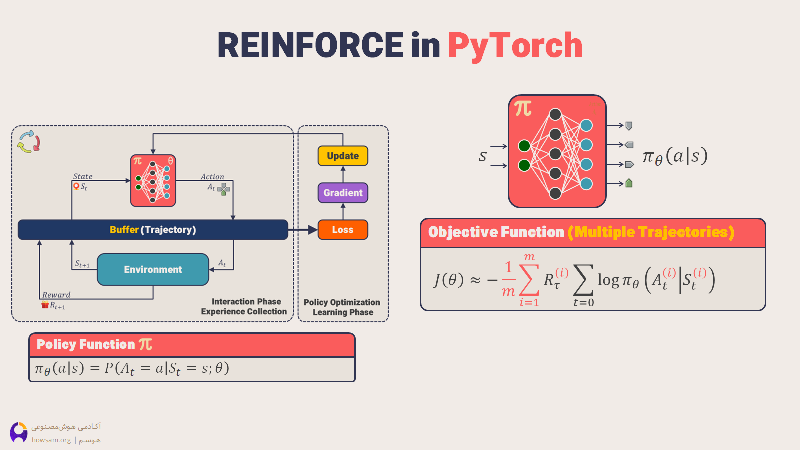

In [22]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

In [10]:
# Define the Policy Network (The red box in the slide)
class PolicyNet(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
        
    def forward(self, x):
        return self.fc(x)

In [53]:
# Initialize environment and network
env = gym.make('LunarLander-v3', render_mode='human')
policy = PolicyNet(env.observation_space.shape[0], env.action_space.n)
optimizer = optim.Adam(policy.parameters(), lr=0.01)

# Main training loop (e.g., 1 sample episode)
for episode in range(100):
    state, info = env.reset()

    # -------------------------------------------------------------
    # Buffer (Trajectory) Box: Storage for interaction data
    # -------------------------------------------------------------
    saved_log_probs = []
    rewards = []

    done = False
    while not done:
        # Interaction Phase
        state_tensor = torch.FloatTensor(state)
        action_probs = policy(state_tensor)

        # Sample an action (Stochastic Policy implementation)
        m = Categorical(action_probs)
        action = m.sample()

        # Save to Buffer
        saved_log_probs.append(m.log_prob(action))

        # Step the environment to get next state and reward
        state, reward, terminated, truncated, info = env.step(action.item())
        rewards.append(reward)
        
        done = terminated or truncated

    # -------------------------------------------------------------
    # Learning Phase: Policy Optimization after episode completion
    # -------------------------------------------------------------

    # Calculate total trajectory reward (R_tau)
    R_tau = sum(rewards)

    # Calculate Loss (The orange box in the slide)
    policy_loss = -torch.stack(saved_log_probs).sum() * R_tau

    # Compute Gradient and Apply Update (The purple and yellow boxes)
    optimizer.zero_grad()
    policy_loss.backward() # Compute gradients
    optimizer.step()        # Update policy network weights

    print(f"Episode {episode} finished! Total Reward (R_tau): {R_tau}")

env.close()

Episode 0 finished! Total Reward (R_tau): -83.47244760631146
Episode 1 finished! Total Reward (R_tau): -379.18307021635326
Episode 2 finished! Total Reward (R_tau): -57.38803564142266
Episode 3 finished! Total Reward (R_tau): -361.6920032163644
Episode 4 finished! Total Reward (R_tau): -90.77567796355316
Episode 5 finished! Total Reward (R_tau): -285.83637591278114
Episode 6 finished! Total Reward (R_tau): -228.30441735044315
Episode 7 finished! Total Reward (R_tau): -114.59841269792196
Episode 8 finished! Total Reward (R_tau): -194.21326753236127
Episode 9 finished! Total Reward (R_tau): -125.06966947978003
Episode 10 finished! Total Reward (R_tau): -283.29165985067095
Episode 11 finished! Total Reward (R_tau): -293.6284986236651
Episode 12 finished! Total Reward (R_tau): -335.2821097310584
Episode 13 finished! Total Reward (R_tau): -211.9748267301386
Episode 14 finished! Total Reward (R_tau): -238.92228238600472
Episode 15 finished! Total Reward (R_tau): -98.30060462280197
Episode 16

# 🔴 **A2C**

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

In [7]:
class PolicyNet(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
    def forward(self, x): 
        return self.fc(x)

In [8]:
class ValueNet(nn.Module):
    def __init__(self, state_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x): 
        return self.fc(x)

In [10]:
env = gym.make('LunarLander-v3', render_mode='human')
state_dim = env.observation_space.shape[0]

policy = PolicyNet(state_dim, env.action_space.n)
value_net = ValueNet(state_dim)

optimizer = optim.Adam(list(policy.parameters()) + list(value_net.parameters()), lr=0.001)
gamma = 0.99

for episode in range(5000):
    state, info = env.reset()

    # -------------------------------------------------------------
    # Interaction Phase: Experience Collection (Matches your diagram)
    # -------------------------------------------------------------
    saved_log_probs = []
    rewards = []
    saved_values = [] # Matches the 'Value (Vt)' arrow going into Buffer

    done = False
    while not done:
        state_tensor = torch.FloatTensor(state)

        # 1. Actor predicts Action (At) & Critic predicts Value (Vt)
        action_probs = policy(state_tensor)
        state_value = value_net(state_tensor) # Calculated on the fly

        # 2. Sample action
        m = Categorical(action_probs)
        action = m.sample()

        # 3. Save everything to Buffer (Trajectory) Box
        saved_log_probs.append(m.log_prob(action))
        saved_values.append(state_value) # Value is packed into buffer here

        # 4. Step the environment to get Next State and Reward (Rt+1)
        state, reward, terminated, truncated, info = env.step(action.item())
        rewards.append(reward)
        
        done = terminated or truncated

    # -------------------------------------------------------------
    # Learning Phase (Triggered after episode)
    # -------------------------------------------------------------
    
    # 1. Compute discounted rewards (Returns) from end to start
    discounted_returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        discounted_returns.insert(0, G)
        
    returns = torch.FloatTensor(discounted_returns)
    log_probs_tensor = torch.stack(saved_log_probs)
    
    # Unpack Values directly from Buffer (No need to pass states to network again)
    state_values_tensor = torch.stack(saved_values).squeeze()

    # 2. Calculate Advantage (Gt - Vt)
    advantage = returns - state_values_tensor

    # 3. Compute losses (Matches the Orange Loss Box)
    actor_loss = -(log_probs_tensor * advantage.detach()).sum()
    critic_loss = nn.MSELoss()(state_values_tensor, returns) # advantage**2
    
    total_loss = actor_loss + critic_loss

    # 4. Gradient & Update Boxes
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    print(f"Episode {episode} finished! Total Reward: {sum(rewards)}")

env.close()

Episode 0 finished! Total Reward: -406.8710751575824
Episode 1 finished! Total Reward: -133.3936608935255
Episode 2 finished! Total Reward: -360.95134610256093
Episode 3 finished! Total Reward: -144.29305475214204
Episode 4 finished! Total Reward: -441.5055356815247
Episode 5 finished! Total Reward: -346.3909312756437
Episode 6 finished! Total Reward: -87.31307727549756
Episode 7 finished! Total Reward: -160.64903556182907
Episode 8 finished! Total Reward: -250.22637907203833
Episode 9 finished! Total Reward: -128.8570245404889
Episode 10 finished! Total Reward: -97.40100499499434
Episode 11 finished! Total Reward: -319.5190702643713
Episode 12 finished! Total Reward: -370.2232274526947
Episode 13 finished! Total Reward: -83.89227377224437
Episode 14 finished! Total Reward: -222.3096559441566
Episode 15 finished! Total Reward: -309.23027230782077
Episode 16 finished! Total Reward: -120.72196951284221
Episode 17 finished! Total Reward: -122.6758950678142
Episode 18 finished! Total Rewar

KeyboardInterrupt: 

In [11]:
# 1. Initialize the environment for evaluation (with human rendering)
env = gym.make('LunarLander-v3', render_mode='human')

# 2. Put networks into evaluation mode (Disables dropout/batchnorm if any)
policy.eval()

print("--- Starting Evaluation (Testing) ---")

# Run for a few test episodes (e.g., 5 episodes)
for episode in range(5):
    state, info = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        # Convert state to tensor without tracking gradients
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state)
            
            # Get action probabilities from the trained policy
            action_probs = policy(state_tensor)
            
            # Select the absolute best action (Deterministic)
            action = torch.argmax(action_probs).item()

        # Step the environment
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        
        done = terminated or truncated

    print(f"Test Episode {episode} finished! Total Reward: {total_reward}")

env.close()

--- Starting Evaluation (Testing) ---
Test Episode 0 finished! Total Reward: 233.47915316253707
Test Episode 1 finished! Total Reward: 265.7327149760671
Test Episode 2 finished! Total Reward: 218.82382047819561
Test Episode 3 finished! Total Reward: 208.0996538729665
Test Episode 4 finished! Total Reward: 201.78890689111375


## 🟠 Online

In [12]:
# Initialize environment and networks
env = gym.make('LunarLander-v3', render_mode='human')
state_dim = env.observation_space.shape[0]

policy = PolicyNet(state_dim, env.action_space.n)
value_net = ValueNet(state_dim) # Added Critic

# Combined optimizer for both networks
optimizer = optim.Adam(list(policy.parameters()) + list(value_net.parameters()), lr=0.003)

gamma = 0.99 # Discount factor needed for A2C TD-error

# Main training loop
for episode in range(5000):
    state, info = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        state_tensor = torch.FloatTensor(state)
        
        # Actor: Predict action probabilities
        action_probs = policy(state_tensor)
        m = Categorical(action_probs)
        action = m.sample()
        log_prob = m.log_prob(action)

        # Critic: Predict value of current state V(s)
        state_value = value_net(state_tensor)

        # Step the environment
        next_state, reward, terminated, truncated, info = env.step(action.item())
        total_reward += reward
        done = terminated or truncated

        # Calculate TD Target and Advantage
        if done:
            td_target = torch.FloatTensor([reward])
        else:
            next_state_tensor = torch.FloatTensor(next_state)
            # Bootstrapping using next state value (handles truncated perfectly)
            td_target = reward + gamma * value_net(next_state_tensor).detach()
        
        # Advantage = Actual/Estimated Target - Critic's Guess
        advantage = td_target - state_value

        # Calculate Loss for both Actor and Critic
        actor_loss = -log_prob * advantage.detach()
        critic_loss = advantage.pow(2) # Mean Squared Error for Critic
        
        # Total Loss to minimize
        loss = actor_loss + critic_loss

        # Compute Gradient and Apply Update instantly per step (Online A2C)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        state = next_state

    print(f"Episode {episode} finished! Total Reward: {total_reward}")

env.close()

Episode 0 finished! Total Reward: -509.74253260141614
Episode 1 finished! Total Reward: -275.0756385140262
Episode 2 finished! Total Reward: -140.11532998311043
Episode 3 finished! Total Reward: -185.77840972745258
Episode 4 finished! Total Reward: -218.44004498489824
Episode 5 finished! Total Reward: -434.60105489312025
Episode 6 finished! Total Reward: -97.35194254572077
Episode 7 finished! Total Reward: -179.2607060272761
Episode 8 finished! Total Reward: -502.8576712646704
Episode 9 finished! Total Reward: -183.57692611944884
Episode 10 finished! Total Reward: -613.1618578419103
Episode 11 finished! Total Reward: -911.1217297276022
Episode 12 finished! Total Reward: -805.1717849694527
Episode 13 finished! Total Reward: -257.8609406539613
Episode 14 finished! Total Reward: -773.8171717917068
Episode 15 finished! Total Reward: -579.6854655896282
Episode 16 finished! Total Reward: -670.5946789674914
Episode 17 finished! Total Reward: -735.3574389621102
Episode 18 finished! Total Rewar

KeyboardInterrupt: 

# 🔴 **PPO**

In [7]:
import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim

from torch.distributions import Categorical

In [8]:
class PolicyNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return Categorical(logits=self.net(x))

In [9]:
class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [15]:
env = gym.make("LunarLander-v3", render_mode="human")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

gamma = 0.99
gae_lambda = 0.95

clip_eps = 0.2
value_coef = 0.5
entropy_coef = 0.01


policy = PolicyNet().to(device)
value = ValueNet().to(device)

lr = 3e-4
optimizer = optim.Adam(list(policy.parameters()) + list(value.parameters()), lr=lr)

rollout_size = 2048
update_epochs = 10

device = "cuda" if torch.cuda.is_available() else "cpu"
num_updates = 500

# Reset the environment before training starts
state, _ = env.reset()

for update in range(num_updates):

    # -------------------------------------------------------------
    # Interaction Phase: Rollout Collection
    # -------------------------------------------------------------
    # Collect one rollout using the current policy.
    # Each transition stores:
    #   (State, Action, Reward, Done, Value, Log Probability)
    states = []
    actions = []
    rewards = []
    dones = []
    values = []
    log_probs = []

    for _ in range(rollout_size):

        state_tensor = torch.tensor(state, dtype=torch.float32, device=device)

        # 1. Actor predicts an action distribution
        #    Critic predicts the state value
        with torch.no_grad():
            dist = policy(state_tensor)
            value_pred = value(state_tensor)

            action = dist.sample()
            log_prob = dist.log_prob(action)

        # 2. Execute the selected action
        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        # 3. Store the transition in the rollout buffer
        states.append(state)
        actions.append(action.item())
        rewards.append(reward)
        dones.append(done)
        values.append(value_pred.item())
        log_probs.append(log_prob.item())

        state = next_state

        if done:
            state, _ = env.reset()

    # -------------------------------------------------------------
    # Learning Phase
    # -------------------------------------------------------------

    # 1. Estimate the value of the state immediately after the rollout (Bootstrap Value)
    with torch.no_grad():
        next_value = value(torch.tensor(state, dtype=torch.float32, device=device)).item()

    # 2. Compute Generalized Advantage Estimation (GAE) by traversing the rollout backward
    advantages = []
    gae = 0.0
    for t in reversed(range(rollout_size)):
        mask = 1.0 - dones[t]
        next_v = next_value if t == rollout_size - 1 else values[t + 1]

        # TD Error
        delta = rewards[t] + gamma * next_v * mask - values[t]

        # Recursive GAE computation
        gae = delta + gamma * gae_lambda * mask * gae

        advantages.append(gae)

    advantages.reverse()

    # 3. Convert the rollout into tensors
    states = torch.tensor(states, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, device=device)
    values = torch.tensor(values, dtype=torch.float32, device=device)
    old_log_probs = torch.tensor(log_probs, dtype=torch.float32, device=device)
    advantages = torch.tensor(advantages, dtype=torch.float32, device=device)

    # 4. Compute Value Targets
    returns = advantages + values

    # 5. Normalize advantages for more stable optimization
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # -------------------------------------------------------------
    # PPO Optimization Phase
    # -------------------------------------------------------------
    # Reuse the same rollout for multiple optimization epochs
    for _ in range(update_epochs):

        # 1. Evaluate the current policy on the collected rollout
        dist = policy(states)
        new_log_probs = dist.log_prob(actions)

        # 2. Compute the importance sampling ratio
        ratio = (new_log_probs - old_log_probs).exp()

        # 3. Compute the PPO clipped surrogate objective
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages

        policy_loss = -torch.min(surr1, surr2).mean()

        # 4. Compute the Critic loss
        value_loss = (value(states) - returns).pow(2).mean()

        # 5. Encourage policy exploration
        entropy = dist.entropy().mean()

        # 6. Combine all losses into the final PPO objective
        loss = policy_loss + value_coef * value_loss - entropy_coef * entropy

        # 7. Update both Actor and Critic
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Update {update:3d} | Return {returns.mean():7.2f} | Policy {policy_loss:.3f} | Value {value_loss:.3f}")

env.close()

Update   0 | Return  -30.39 | Policy -0.005 | Value 1777.540
Update   1 | Return  -30.17 | Policy -0.003 | Value 1653.693
Update   2 | Return  -24.88 | Policy -0.006 | Value 1222.441
Update   3 | Return  -27.65 | Policy -0.006 | Value 1503.003
Update   4 | Return  -31.78 | Policy -0.002 | Value 1927.925
Update   5 | Return  -24.92 | Policy -0.004 | Value 1166.764
Update   6 | Return  -25.46 | Policy -0.006 | Value 1072.080
Update   7 | Return  -19.01 | Policy -0.003 | Value 906.189
Update   8 | Return  -18.90 | Policy -0.004 | Value 850.956
Update   9 | Return  -17.56 | Policy -0.010 | Value 845.636
Update  10 | Return  -22.16 | Policy -0.001 | Value 1271.262
Update  11 | Return  -24.72 | Policy -0.003 | Value 1035.235
Update  12 | Return  -24.22 | Policy -0.005 | Value 1421.194
Update  13 | Return  -25.96 | Policy -0.006 | Value 1283.711
Update  14 | Return  -12.68 | Policy -0.005 | Value 554.967
Update  15 | Return  -19.33 | Policy -0.006 | Value 908.321
Update  16 | Return  -18.22 |

KeyboardInterrupt: 